# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-algorithm` 中的 QAOA 求解 MaxCut 问题。

In [2]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions
print('Imports ready')

Imports ready


## 1. 定义 MaxCut 实例

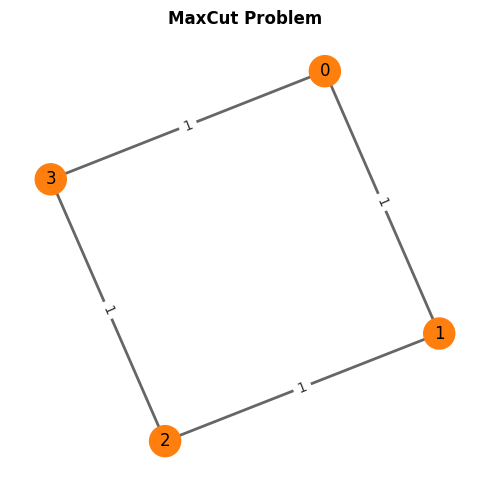

In [3]:
weights =  {(0,1):1, (1,2):1, (2,3):1, (3,0):1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title='MaxCut Problem')

## 2. Maxcut → QUBO

In [4]:
qubo  = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Q = [
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
]
c = [2.000, 2.000, 2.000, 2.000]
offset = 0.000



## 3. QUBO → Ising

In [5]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

[iter=  1] f=-0.626 theta=[2.065, -0.465, -0.465, -1.065, -1.065, 1.465]
[iter=  2] f=-0.614 theta=[2.427, -0.827, -0.103, -1.427, -1.427, 1.827]
[iter=  3] f=-0.870 theta=[2.628, -1.028, 0.098, -1.227, -1.628, 1.627]
[iter=  4] f=0.244 theta=[2.088, -1.567, 0.637, -0.688, -1.088, 2.167]
[iter=  5] f=-0.214 theta=[1.857, -1.799, 0.405, -0.920, -0.857, 1.935]
[iter=  6] f=-0.196 theta=[1.644, -2.011, 0.193, -0.708, -1.069, 1.723]
[iter=  7] f=-0.100 theta=[1.926, -1.729, -0.089, -0.426, -1.351, 2.004]
[iter=  8] f=-0.282 theta=[1.829, -1.632, -0.186, -0.329, -1.254, 2.101]
[iter=  9] f=-0.348 theta=[1.642, -1.820, 0.002, -0.141, -1.442, 2.289]
[iter= 10] f=-0.502 theta=[1.739, -1.723, -0.096, -0.239, -1.344, 2.191]
[iter= 11] f=-0.552 theta=[1.699, -1.682, -0.136, -0.199, -1.304, 2.151]
[iter= 12] f=-0.546 theta=[1.736, -1.719, -0.173, -0.162, -1.267, 2.188]
[iter= 13] f=-0.516 theta=[1.861, -1.594, -0.298, -0.287, -1.393, 2.062]
[iter= 14] f=-0.568 theta=[1.817, -1.550, -0.342, -0.243,

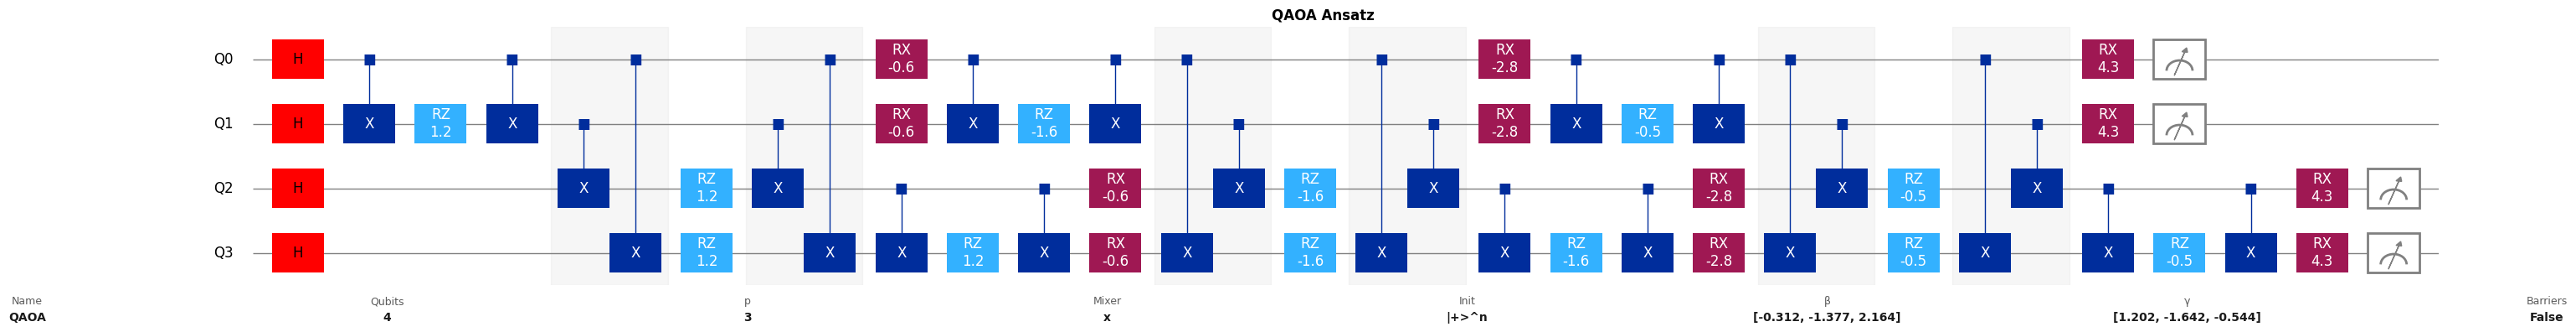

In [6]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 50, "a": 0.2, "c": 0.2})
solver = QAOASolver(ising, 
                    runner=LocalRunner(), 
                    qaoa_cfg=QAOAConfig(reps=3, mixer="x"), 
                    opt_cfg=opt_cfg)
res = solver.run()

## 5. 可视化：运行结果

In [7]:
res.print_result()


========== [ Experiment Information ] ==========
任务ID     : 20251009152831
shots 数量 : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 50, 'a': 0.2, 'c': 0.2}}

========== [ Measurement Results ] ==========
probability : {'1010': 0.495, '0101': 0.457, '0100': 0.006, '1100': 0.006, '0001': 0.005, '0010': 0.005, '0110': 0.005, '1001': 0.005, '1011': 0.005, '1000': 0.003, '0011': 0.002, '0111': 0.002, '1101': 0.002, '1110': 0.002}


## 6. 可视化：迭代曲线与概率分布

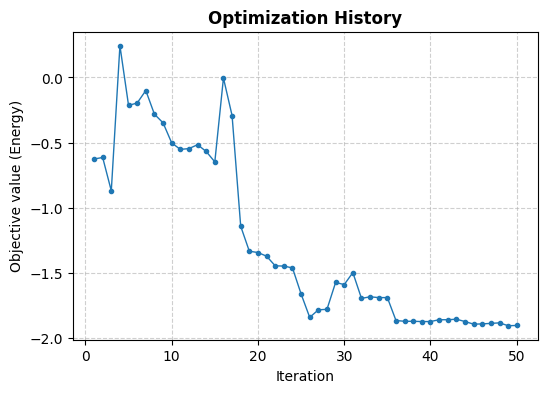

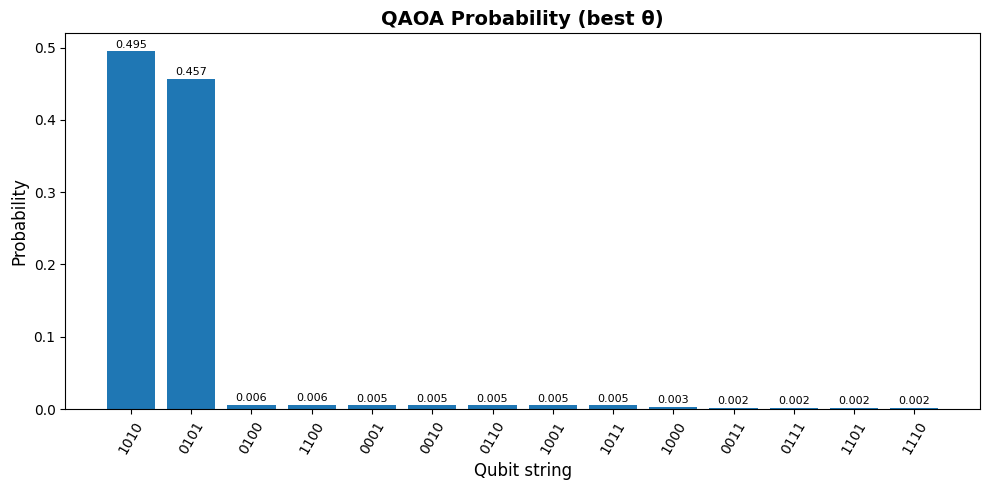

In [8]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [1.202, -1.642, -0.544]
Best betas  : [-0.312, -1.377, 2.164]
Best energy : -1.904
Best Qubit string:  1010
Best solution: [0, 2]
Max-Cut value: 4.000


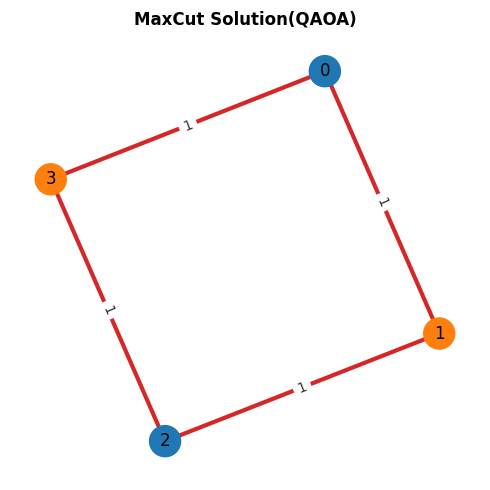

[0, 2]

In [10]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
